In [12]:
#data auditing and cleaning data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
import os

In [3]:
sys.path.append(os.path.abspath("C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/src"))
os.listdir("C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/src")

['utils.py', '__pycache__']

In [4]:
#loading the data
df=pd.read_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/raw/train.csv')
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
print('The shape of the data is:',df.shape)

The shape of the data is: (1460, 81)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

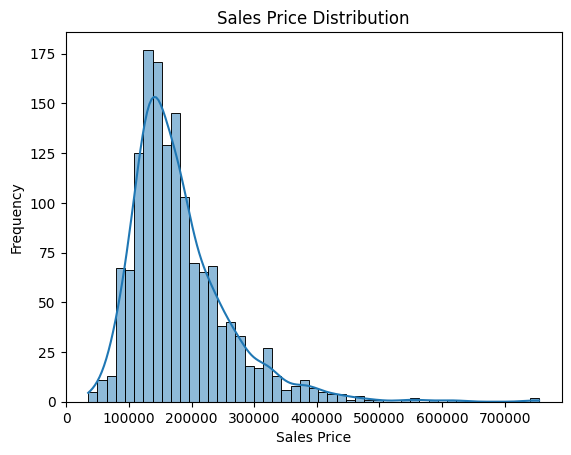

In [14]:
sns.histplot(df['SalePrice'],kde=True)
plt.title('Sales Price Distribution')
plt.xlabel('Sales Price')
plt.ylabel('Frequency')
plt.show()

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
df.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

In [10]:
print('Percentage of missing values in each column :\n',df.isnull().sum()/len(df)*100)

Percentage of missing values in each column :
 Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64


In [17]:
numerical_cols=df.select_dtypes(include=[int,float]).columns
categorical_cols=df.select_dtypes(include=[object]).columns
print('Numerical columns:',len(numerical_cols))
print('Categorical columns:',len(categorical_cols))

Numerical columns: 38
Categorical columns: 43


C:\Users\kasir\AppData\Local\Temp\ipykernel_6768\1641937621.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=df.select_dtypes(include=[object]).columns


In [11]:
from utils import data_audit
audit=data_audit(df)
audit.head(20)


,Data Type,Missing Values,Unique Values,Percentage Missing
PoolQC,str,1453,3,99.520548
MiscFeature,str,1406,4,96.301370
Alley,str,1369,2,93.767123
Fence,str,1179,4,80.753425
MasVnrType,str,872,3,59.726027
FireplaceQu,str,690,5,47.260274
LotFrontage,float64,259,110,17.739726
GarageQual,str,81,5,5.547945
GarageFinish,str,81,3,5.547945
GarageType,str,81,6,5.547945


In [19]:
audit.to_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/processed/data_audit.csv')

### **Summary of the Data**

# Key Observations

• Dataset contains 1460 observations and 81 features  
• Several columns contain high missing values (>80%)  
• Target variable SalePrice is right-skewed  
• Dataset contains both numerical and categorical features
